# Gurobi Monotonic Approximation of Prices
version 1.1

In [17]:
# Let's start off by loading in the packages

# Let's load in the necessary packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
#import gurobipy as gp
#from gurobipy import GRB
import numpy as np
from scipy.optimize import curve_fit

### Loading in some data

In [50]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "he", "size","flexible","price","ail","mkt_price"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
#merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
merit_data = workbook
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

In [51]:
bids = merit_data.query('he==15')
bids=bids.sort_values('price').reset_index(drop = True)
# bids=bids.assign(merit=bids['size'].cumsum())
bids['merit'] = bids['size'].cumsum() # Old code is above

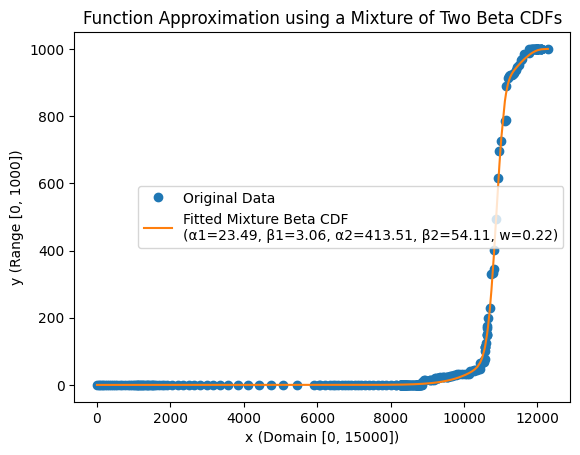

In [60]:
from scipy.stats import beta

# Example data (you would use your actual data here)
#data = np.random.beta(2, 5, size=1000)  # Example data from a Beta distribution

# Fit the Beta distribution to the data
#alpha, beta_param, loc, scale = beta.fit(data, floc=0, fscale=1)  # Force it to be in [0, 1]

bids_temp=bids
x = bids_temp['merit']
x = x.to_numpy()
y = bids_temp['price']

# Normalize the domain (x) to [0, 1]
x_normalized = (x - np.min(x)) / (np.max(x) - np.min(x))

# Normalize the range (y) to [0, 1]
y_normalized = (y - np.min(y)) / (np.max(y) - np.min(y))

# Define the weighted mixture of two Beta CDFs
def mixture_beta_cdf(x, alpha1, beta1, alpha2, beta2, w):
    beta_cdf1 = beta.cdf(x, alpha1, beta1)
    beta_cdf2 = beta.cdf(x, alpha2, beta2)
    return w * beta_cdf1 + (1 - w) * beta_cdf2

# Fit the mixture Beta CDF to the normalized data
popt, _ = curve_fit(mixture_beta_cdf, x_normalized, y_normalized, p0=[2, 5, 5, 2, 0.5])

# Retrieve fitted parameters
alpha1_fitted, beta1_fitted, alpha2_fitted, beta2_fitted, w_fitted = popt

# Approximate y using the fitted mixture Beta CDF
y_approx_normalized = mixture_beta_cdf(x_normalized, alpha1_fitted, beta1_fitted, alpha2_fitted, beta2_fitted, w_fitted)

# Rescale the approximated y back to original range [0, 1000]
y_approx = y_approx_normalized * (1000 - 0) + 0  # Range [0, 1000]

# Plot the original data and the approximation
plt.plot(x, y, 'o', label='Original Data')
plt.plot(x, y_approx, '-', label=f'Fitted Mixture Beta CDF\n(α1={alpha1_fitted:.2f}, β1={beta1_fitted:.2f}, α2={alpha2_fitted:.2f}, β2={beta2_fitted:.2f}, w={w_fitted:.2f})')
plt.title("Function Approximation using a Mixture of Two Beta CDFs")
plt.xlabel('x (Domain [0, 15000])')
plt.ylabel('y (Range [0, 1000])')
plt.legend()
plt.show()

Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]
Starting values: [2, 5, 5, 2, 0.5, 0]


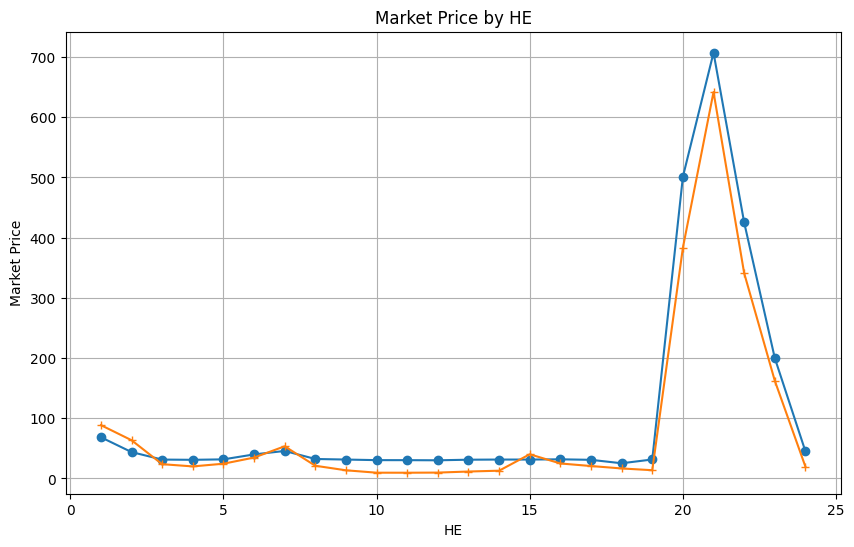

In [104]:
def mixture_beta_cdf(x, *params):
    alpha1 = params[0]
    beta1 = params[1]
    alpha2 = params[2]
    beta2 = params[3]
    w = params[4]
    shift = params[5]
    
    beta_cdf1 = beta.cdf(x, alpha1, beta1)
    beta_cdf2 = beta.cdf(x, alpha2, beta2)
    
    return w * beta_cdf1 + (1 - w) * beta_cdf2 + shift

def approx_merit(bids, start_vals):
    """
    Fit a mixture of two Beta CDFs to normalized data from the 'merit' and 'price' columns of bids.
    
    Parameters:
    bids (DataFrame): Data containing 'merit' and 'price' columns.
    start_vals (list): Starting values for the parameters.

    Returns:
    tuple: Vector of parameters for defining the mixed beta CDF and the maximum merit value.
    """
    # Extract data from bids
    x = bids['merit'].to_numpy()
    y = bids['price'].to_numpy()
    
    # Normalize x (domain) and y (range) to [0, 1]
    x_max = np.max(x)
    x_normalized = x / x_max
    y_normalized = y / 1000  # Prices are always bounded between 0 and 1000
  
    # Print the start values for debugging
    print("Starting values:", start_vals)
    
    # Fit the mixture Beta CDF to the normalized data
    popt, _ = curve_fit(mixture_beta_cdf, x_normalized, y_normalized, p0=start_vals)
    
    return popt, x_max

# Example starting values
initial_params = [2, 5, 5, 2, 0.5, 0]  # Initial guess for parameters
#start_vals, max_merit = approx_merit(bids_temp, initial_params)

#print("Fitted parameters:", start_vals)

#ail_target=bids_temp['ail'].iat[0]
#ail_norm=ail_target/max_merit

#print(mixture_beta_cdf(ail_norm, alpha1_fitted, beta1_fitted, alpha2_fitted, beta2_fitted, w_fitted)*1000)


#print(bids_temp['mkt_price'].iat[0])
#print(parameters)

for (date, he), group in merit_data.groupby(['date', 'he']):
  bids = group
  bids=bids.sort_values('price').reset_index(drop = True)
  #bids=bids.assign(merit=bids['size'].cumsum())
  bids['merit'] = bids['size'].cumsum() # Old code is above 
  parameters, max_merit = approx_merit(bids,initial_params)
  ail_target=bids['ail'].iat[0]
  ail_norm=ail_target/max_merit
  merit_data.loc[group.index, 'approx_price'] = mixture_beta_cdf(ail_norm, *parameters)*1000

avg_mkt_price_by_he = merit_data.groupby('he')['mkt_price'].mean()
approx_mkt_price_by_he = merit_data.groupby('he')['approx_price'].mean()
# Plot the original data and the approximation
plt.figure(figsize=(10, 6))
avg_mkt_price_by_he.plot(kind='line', marker='o')
approx_mkt_price_by_he.plot(kind='line', marker='+')
plt.title(f"Market Price by HE")
plt.xlabel("HE")
plt.ylabel("Market Price")
plt.grid(True)
plt.show()


In [16]:
import gurobipy as gp
from gurobipy import GRB

# Define the supply function
def supply_function(Q):
    return 4 * Q  # You can modify this function to any supply relationship

# Create a new model
m = gp.Model("supply_demand_equilibrium")

# Add a variable for quantity Q
Q = m.addVar(name="Q", lb=0)  # Non-negative quantity

# Add a variable for price P
P = m.addVar(name="P")

# Set objective to minimize (no objective needed for equilibrium, so set it to 0)
m.setObjective(0, GRB.MINIMIZE)

# Add constraints for demand and supply
m.addConstr(P == 40 - 5 * Q, "demand")
# For the supply side, call the supply_function to determine the price
m.addConstr(P == supply_function(Q), "supply")
# Optimize the model
m.optimize()

# Retrieve the equilibrium quantity and price
if m.status == GRB.OPTIMAL:
    equilibrium_Q = Q.X
    equilibrium_P = P.X
    print(f"Equilibrium Quantity (Q): {equilibrium_Q}")
    print(f"Equilibrium Price (P): {equilibrium_P}")

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Academic license 2565375 - for non-commercial use only - registered to al___@ualberta.ca
Optimize a model with 2 rows, 2 columns and 4 nonzeros
Model fingerprint: 0x52c49c99
Coefficient statistics:
  Matrix range     [1e+00, 5e+00]
  Objective range  [0e+00, 0e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 4e+01]
Presolve removed 2 rows and 2 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  0.000000000e+00
Equilibrium Quantity (Q): 4.444444444444445
Equilibrium Price (P): 17.77777777777778
